## Feature Extraction
The code is similar to the one used for data visualization, but instead of printing (visualizing) the extracted features, they are saved in a .csv file ("extracted_features_emotion_centric.csv").
In the end, the dataset will contain a large number of features, from which it is necessary to choose the most significant ones, depending on the chosen approach.

#### IMPORTS

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import math

#### INITIALIZATION

In [2]:
# --- CONFIGURAZIONE GLOBALE ---
ROOT_DIR = Path("C:/Users/Giuseppe/AppData/Roaming/JetBrains/PyCharm2025.1/extensions/com.intellij.database/data/video_tesi")
SLIDING_WINDOW_SIZE = 30    # Dimensione della finestra di frame per la baseline stabile
BASELINE_SEARCH_RANGE = 100 # Numero di frame iniziali su cui cercare la baseline stabile
FRAME_RATE = 30             # Assumiamo 30 FPS per il calcolo del Reaction Time

# Inizializzazione MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Indici dei landmark (Usa gli indici definiti nel tuo codice)
MOUTH_INDICES = [61, 291, 0, 17, 306, 76]
EYE_INDICES = [33, 133, 160, 158, 144, 153]
EYEBROW_INDICES = [55, 65, 52, 53, 46, 285, 295, 282, 283, 276]

# --- FUNZIONI AUSILIARIE ---

def euclidean_distance(lm1, lm2, W, H):
    # Calcola la distanza tra due punti (teorema di Pitagora).
    # Moltiplichiamo per W e H per avere pixel reali, non numeri 0.0-1.0.
    # Trasforma coordinate 0-1 in Pixel reali (Isotropia)
    x1, y1 = lm1.x * W, lm1.y * H
    x2, y2 = lm2.x * W, lm2.y * H
    return math.hypot(x1 - x2, y1 - y2)

def calculate_face_scale(landmarks, W, H):
    # Unità di misura: Naso (1) - Mento (152)
    # Questa misura ci serve come "righello".
    # Se il paziente si avvicina alla webcam, tutto diventa più grande.
    # Dividendo per questo valore, normalizziamo i dati:
    # Un sorriso a 1 metro e un sorriso a 50cm avranno lo stesso valore numerico.
    return euclidean_distance(landmarks[1], landmarks[152], W, H)

def calculate_mar(landmarks, W, H):
    # Mouth Aspect Ratio (MAR): Quanto è aperta la bocca?
    # Rapporto tra altezza (A+B) e larghezza (C).
    pts = [landmarks[i] for i in MOUTH_INDICES]
    A = euclidean_distance(pts[1], pts[5], W, H)
    B = euclidean_distance(pts[2], pts[4], W, H)
    C = euclidean_distance(pts[0], pts[3], W, H)
    return (A + B) / (2.0 * C) # Rapporto: non serve scala esterna

def calculate_ear(landmarks, W, H):
    pts = [landmarks[i] for i in EYE_INDICES]
    A = euclidean_distance(pts[1], pts[5], W, H)
    B = euclidean_distance(pts[2], pts[4], W, H)
    C = euclidean_distance(pts[0], pts[3], W, H)
    return (A + B) / (2.0 * C) # Rapporto: non serve scala esterna

def calculate_cheek_lift(landmarks, W, H):
    # Misura quanto si alzano le guance (segno tipico del sorriso vero/Duchenne).
    # Qui usiamo 'v_scale' per normalizzare.
    v_scale = calculate_face_scale(landmarks, W, H)
    dist_L = euclidean_distance(landmarks[123], landmarks[61], W, H)
    dist_R = euclidean_distance(landmarks[352], landmarks[291], W, H)
    return dist_L / v_scale, dist_R / v_scale # Normalizzato su volto

def calculate_eyebrow_position(landmarks, W, H):
    v_scale = calculate_face_scale(landmarks, W, H)
    eyebrow_mean_y = np.mean([landmarks[i].y for i in EYEBROW_INDICES])
    # Distanza verticale tra naso e sopracciglia in pixel
    vertical_offset_px = abs((landmarks[1].y - eyebrow_mean_y) * H)
    return vertical_offset_px / v_scale # Normalizzato su volto

def plot_visual_control(movements, threshold, rt_frame, feature_name):
    plt.figure(figsize=(10, 4))
    plt.plot(movements, label='Segnale Normalizzato', color='#2c3e50')
    plt.axhline(y=threshold, color='red', linestyle='--', label='Soglia RT')
    if rt_frame:
        plt.axvline(x=rt_frame, color='orange', label=f'RT: {rt_frame}f')
    plt.title(f"Controllo: {feature_name.upper()}")
    plt.legend()
    plt.show()

In questa porzione di codice entra nella cartella root dir e inizia a cercare tutti i video con estensione.mov.
per ogni video capisce se sano o se malato in base a hp o sp e quale emozione ha ad esso associato.
viene chiamata la funzione extract_features_for_video
che in input diamo i video e per ogni fotogramma mediapipe individua 468 punti del viso(bocca, occhi, guance e sopracciglia)e tutto viene normalizzato rispetto alla grandezza del volto(distanza naso(1)-mento(152)), infine tutti questi dati vengono messi in una lista(all_frames_data).
ricerchiamo una baseline ovvero esamina i primi 100(circa 3 secondie mezzo) frame per la ricarca della sliding window 30(si sceglie 30 per delle costanti cliniche) frame dove il paziente è piu immobile(ovvero un secondo a 30 fps).
Questa finestra sciviola lungo i 100 frame, analizzando tutte e pozisioni possibilida frame 0-30, 1-31 e cosi via)
Per ogni posizione della finestra, il codice guarda i lankmark e calcola la varianza bassa e quella alta.
la varianza alta ovvero dove i punti si muovo di piu(parlato o altro)
varianza bassa(paziente fermo o neutro)
una volta trovato il blocco piu stabile il coldice calcola la media e la deviazione standard
reaction time identifica il primo frame dove il movimento supera la soglia. il tempo trascorso dall'inizio è il reaction time.
 eitchettatura:paziente sano 0 paziente parkinson 1
 stessa cosa con le emozioni
 raccoglie il tutto in un dizionario chiamato samples.
 infine questi dati vengono trasformati in un dataset per i pazienti: esempio affabile_mar_ e cosi via


#### SLIDING WINDOW

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import math

# --- FUNZIONE DI VISUALIZZAZIONE (Punto 5) ---
def plot_visual_control(movements, threshold, rt_frame, feature_name):
    """
    Genera il grafico per validare che la soglia RT sia corretta.
    """
    plt.figure(figsize=(10, 4))
    plt.plot(movements, label='Movimento (Segnale)', color='#2c3e50', alpha=0.8)
    plt.axhline(y=threshold, color='red', linestyle='--', alpha=0.6, label='Soglia RT')

    if rt_frame is not None and rt_frame > 0:
        plt.axvline(x=rt_frame, color='#e67e22', linestyle='-', linewidth=2, label=f'RT rilevato: {rt_frame}f')
        plt.scatter(rt_frame, movements[rt_frame], color='orange', s=60, zorder=5)

    plt.title(f"Validazione Metrica: {feature_name.upper()}", fontsize=12)
    plt.xlabel("Frame")
    plt.ylabel("Intensità (Normalizzata)")
    plt.legend(loc='upper right', fontsize='small')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

# --- FUNZIONE PRINCIPALE ---
def extract_features_for_video(video_path, visual_debug=False):
    """
    Estrae le feature cinematiche del volto seguendo criteri di analisi robusta:
    1. Calcolo distanze in pixel (Isotropia spaziale)
    2. Normalizzazione anatomica (Riferimento Naso-Mento)
    3. Identificazione baseline a minima varianza (Sliding Window)
    4. Definizione soglia statistica di attivazione (Mean + 2*Std + 0.01)
    """
    cap = cv2.VideoCapture(video_path)
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if W == 0 or H == 0:
        print(f"Errore caricamento video: {video_path}")
        return None

    all_frames_data = []
    frame_idx = 0

    # --- ACQUISIZIONE DATI FRAME PER FRAME ---
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        results = face_mesh.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

        if results.multi_face_landmarks:
            lms = results.multi_face_landmarks[0].landmark

            # Calcolo dei parametri cinematici normalizzati
            # La normalizzazione anatomica garantisce l'invarianza dalla distanza camera
            mar = calculate_mar(lms, W, H)
            ear = calculate_ear(lms, W, H)
            cl_L, cl_R = calculate_cheek_lift(lms, W, H)
            eb = calculate_eyebrow_position(lms, W, H)

            all_frames_data.append({
                'idx': frame_idx,
                'mar': mar, 'ear': ear, 'cl_L': cl_L, 'cl_R': cl_R, 'eyebrow': eb,
                # Coordinate per il calcolo della stabilità della posa
                'lms_raw': np.array([[lm.x, lm.y] for lm in lms])
            })
        frame_idx += 1
    cap.release()

    if len(all_frames_data) < SLIDING_WINDOW_SIZE: return None

    # --- IDENTIFICAZIONE AUTOMATICA DELLA BASELINE (MINIMA VARIANZA) ---
    # Si ricerca l'intervallo di 1 secondo (30 frame) con la massima stabilità posturale
    search_range = min(BASELINE_SEARCH_RANGE, len(all_frames_data) - SLIDING_WINDOW_SIZE)
    min_var = float('inf')
    best_start = 0

    # Non possiamo assumere che il frame 0 sia neutro (magari il paziente stava parlando).
    # Usiamo una "Sliding Window" (finestra scorrevole):
    # Scorriamo i primi 100 frame a blocchi di 30.
    # Cerchiamo il blocco con la varianza MINORE (dove il paziente è stato più fermo).
    for i in range(search_range):
        window_lms = [d['lms_raw'] for d in all_frames_data[i : i + SLIDING_WINDOW_SIZE]]
        current_var = np.var(window_lms)

        if current_var < min_var:
            min_var = current_var
            best_start = i


    # Abbiamo trovato la nostra "Face Neutra" di riferimento.
    baseline_slice = all_frames_data[best_start : best_start + SLIDING_WINDOW_SIZE]

    # --- ANALISI DIFFERENZIALE E RILEVAMENTO REACTION TIME ---
    # Ora analizziamo quando l'emozione "scoppia".
    final_features = {}
    metrics_to_process = ['mar', 'ear', 'cl_L', 'cl_R', 'eyebrow']

    for m in metrics_to_process:# Per ogni metrica (bocca, occhi, sopracciglia...)
        video_vals = np.array([d[m] for d in all_frames_data])
        base_vals = np.array([d[m] for d in baseline_slice])

        # Calcolo dei parametri statistici della baseline
        b_mean = np.mean(base_vals)
        b_std = np.std(base_vals)

        # Quando consideriamo un movimento "reale" e non solo rumore?
        # Regola statistica: Media + 2 volte la Deviazione Standard + un piccolo offset (0.01)
        threshold = b_mean + (2 * b_std) + 0.01

        # Segnale di movimento relativo
        movements = np.abs(video_vals - b_mean)

        # Rilevamento del primo superamento della soglia (Reaction Time)
        # Il rilevamento avviene esclusivamente dopo la finestra di baseline
        rt_frame = next((i for i, v in enumerate(movements) if i > (best_start + SLIDING_WINDOW_SIZE) and v > threshold), None)

        # Archiviazione dei risultati cinematici
        final_features[f'rt_{m}'] = (rt_frame / FRAME_RATE) if rt_frame else -1
        final_features[f'max_{m}_intensity'] = np.max(movements)
        final_features[f'mean_{m}_intensity'] = np.mean(movements)

        if visual_debug:
            plot_visual_control(movements, threshold, rt_frame, m)

    return final_features

#### FEATURES VIDEO AND SAVE CSV


In [4]:
import pandas as pd
from collections import defaultdict
import os


# --- ESECUZIONE ---
samples = defaultdict(dict)
# La lista expressions qui è solo di riferimento, non viene usata nel ciclo di scansione
expressions = ['affabile', 'contemplativo', 'dominante', 'esitante', 'fonazione', 'inorridito', 'interdetto', 'ostile', 'perplesso',
               'rallegrato', 'rilassato', 'sarcastico', 'sbalordito', 'scherzoso', 'soddisfatto', 'spaventato', 'spiritoso',
               'supplichevole', 'terrorizzato', 'teso']


print("Inizio scansione ed estrazione feature (Formato Emotion-Centric)...")

for root, dirs, files in os.walk(ROOT_DIR):
    for file in files:
        # Filtra i file video .mov
        if file.lower().endswith('.mov'):

            full_path = os.path.join(root, file)
            filename = os.path.basename(full_path)

            # Logica di estrazione Gruppo (Label)
            group = None
            if "HP" in filename:
                group = 0 # Healthy Patient
            elif "SP" in filename:
                group = 1 # Parkinson's Patient

            # Identifica l'emozione dalla cartella genitore
            emotion = os.path.basename(root).capitalize()

            # Chiave unica per riga: il nome del video completo (VIDEO ID)
            sample_key = filename.replace('.', '_')

            if group is not None:
                # CHIAMA LA FUNZIONE DEFINITA NEL BLOCCO 2
                features = extract_features_for_video(full_path)

                if features:

                    # *** PUNTO CHIAVE: NESSUN PREFISSO ***
                    # Le feature mantengono i nomi base (es. mean_mar_intensity)
                    samples[sample_key].update(features)

                    # *** PUNTO CHIAVE: AGGIUNGI EMOZIONE COME COLONNA ***
                    samples[sample_key]['label'] = group
                    samples[sample_key]['emotion'] = emotion

                    print(f"✅ Estratte {len(features)} feature per il video {sample_key} ({emotion})")
                else:

                    print(f"❌ SKIPPED: {filename}. Meno di {SLIDING_WINDOW_SIZE} frame rilevati o video corrotto.")




Inizio scansione ed estrazione feature (Formato Emotion-Centric)...
✅ Estratte 15 feature per il video HP_affabile_011_mov (Affabile)
✅ Estratte 15 feature per il video HP_contemplativo_011_mov (Contemplativo)
✅ Estratte 15 feature per il video HP_dominante_011_mov (Dominante)
✅ Estratte 15 feature per il video HP_esitante_011_mov (Esitante)
✅ Estratte 15 feature per il video HP_fonazione_011_mov (Fonazione)
✅ Estratte 15 feature per il video HP_inorridito_011_mov (Inorridito)
✅ Estratte 15 feature per il video HP_interdetto_011_mov (Interdetto)
✅ Estratte 15 feature per il video HP_ostile_011_mov (Ostile)
✅ Estratte 15 feature per il video HP_perplesso_011_mov (Perplesso)
✅ Estratte 15 feature per il video HP_rallegrato_011_mov (Rallegrato)
✅ Estratte 15 feature per il video HP_rilassato_011_mov (Rilassato)
✅ Estratte 15 feature per il video HP_sarcastico_011_mov (Sarcastico)
✅ Estratte 15 feature per il video HP_sbalordito_011_mov (Sbalordito)
✅ Estratte 15 feature per il video HP_sc

#### SAVE (.csv)


Estrazione completata. Creazione DataFrame...
                          rt_mar  max_mar_intensity  mean_mar_intensity  \
HP_affabile_011_mov           -1           0.057136            0.024357   
HP_contemplativo_011_mov      -1           0.093205            0.027825   
HP_dominante_011_mov          -1           0.039588            0.010003   
HP_esitante_011_mov           -1           0.041548            0.017082   
HP_fonazione_011_mov          -1           0.194747            0.060908   

                          rt_ear  max_ear_intensity  mean_ear_intensity  \
HP_affabile_011_mov           -1           0.025800            0.009816   
HP_contemplativo_011_mov      -1           0.029940            0.008622   
HP_dominante_011_mov          -1           0.038116            0.005733   
HP_esitante_011_mov           -1           0.025029            0.007040   
HP_fonazione_011_mov          -1           0.048778            0.011120   

                          rt_cl_L  max_cl_L_intensi

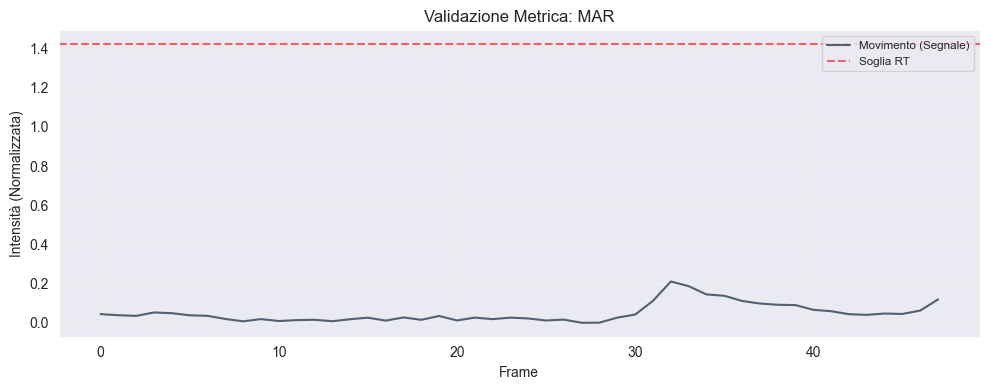

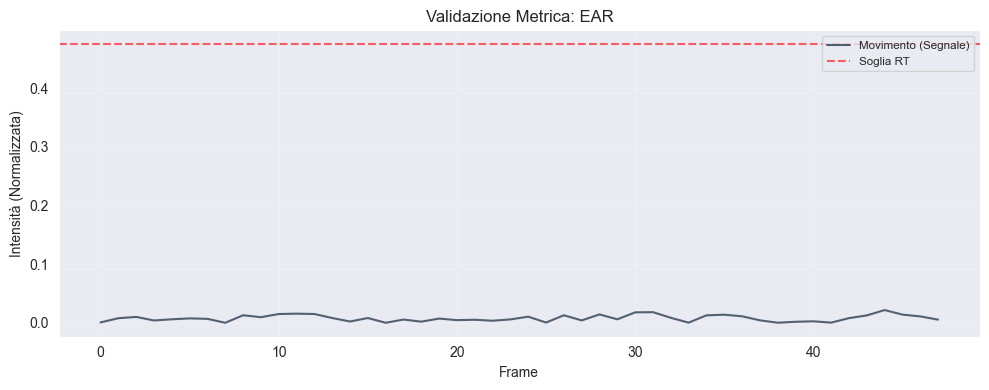

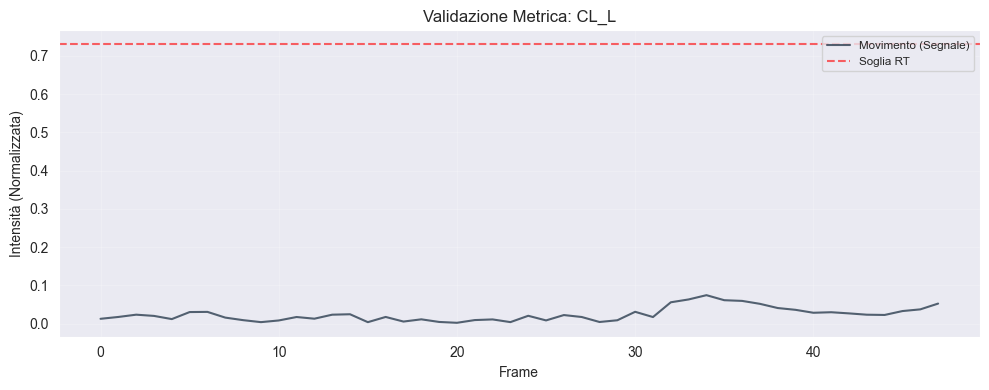

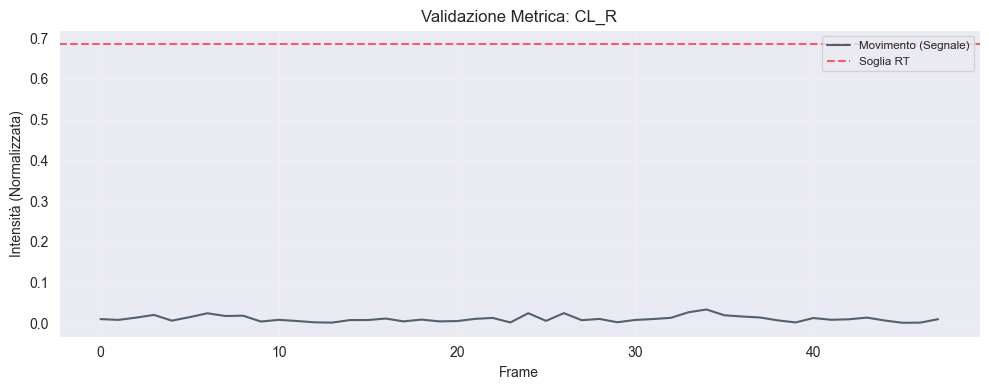

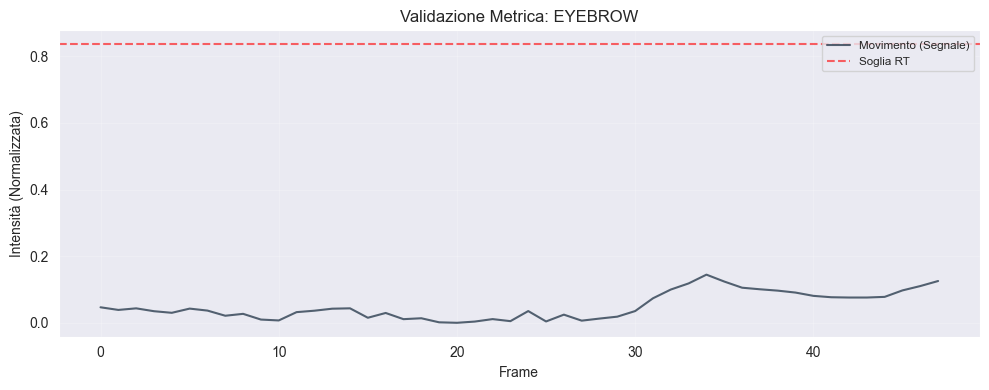

{'rt_mar': -1, 'max_mar_intensity': 0.21074225153905357, 'mean_mar_intensity': 0.0499511609896533, 'rt_ear': -1, 'max_ear_intensity': 0.02173110047189919, 'mean_ear_intensity': 0.007831631300107974, 'rt_cl_L': -1, 'max_cl_L_intensity': 0.07433207224317384, 'mean_cl_L_intensity': 0.02403235403641964, 'rt_cl_R': -1, 'max_cl_R_intensity': 0.033366747906666494, 'mean_cl_R_intensity': 0.010495199755453084, 'rt_eyebrow': -1, 'max_eyebrow_intensity': 0.14471938879125534, 'mean_eyebrow_intensity': 0.050122349834966384}


In [5]:
# --- SALVATAGGIO IN CSV ---
if samples:
    print("\nEstrazione completata. Creazione DataFrame...")
    df = pd.DataFrame.from_dict(samples, orient="index")

    # Riordina le colonne per mettere 'emotion' e 'label' alla fine
    if 'label' in df.columns:
        # Ordina le colonne mantenendo 'emotion' e 'label' alla fine
        cols = [c for c in df.columns if c not in ['label', 'emotion']] + ['emotion', 'label']
        df = df[cols]

    print(df.head())

    # Salva il file con un nome che riflette il formato
    df.to_csv("extracted_features_emotion_centric.csv", index_label="video_id")
    print("\n File 'extracted_features_emotion_centric.csv' salvato con successo.")
else:
    print("\n Nessun dato valido estratto.")
    # Test su un video singolo
video_test = r"C:\Users\Giuseppe\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\data\video_tesi\HP2\Affabile\HP.affabile.02.mov"
risultati = extract_features_for_video(video_test, visual_debug=True)

# Stampa i risultati per vedere se i Reaction Time hanno senso
print(risultati)

In [6]:
# --- CODICE DI SALVATAGGIO OTTIMIZZATO
import pandas as pd
import numpy as np

# 1. Creazione DataFrame dai dati estratti (samples è il dizionario che hai riempito nel ciclo for)
if len(samples) > 0:
    print(f"✅ Estrazione completata su {len(samples)} video. Elaborazione dataset...")
    df_raw = pd.DataFrame.from_dict(samples, orient="index")

    # Se 'video_id' non è una colonna ma l'indice, sistemiamo
    df_raw.reset_index(inplace=True)
    df_raw.rename(columns={'index': 'video_id'}, inplace=True)

    # 2. Creazione colonna ID PAZIENTE (Fondamentale!)
    # Trasforma "HP_affabile_01.mov" -> "HP1"
    def get_patient_id(video_name):
        # Logica: cerca "HP" o "SP" e il numero successivo
        name = str(video_name)
        group = "HP" if "HP" in name else "SP"
        parts = name.replace('.', '_').split('_')
        for part in parts:
            if part.isdigit():
                return f"{group}{int(part)}" # Es: HP1
        return "UNKNOWN"

    df_raw['patient_id'] = df_raw['video_id'].apply(get_patient_id)

    # 3. AGGREGAZIONE (DA VIDEO A PAZIENTE)
    # Calcoliamo Media, Deviazione Standard e Massimo per ogni Emozione
    print("🔹 Aggregazione dati per Paziente in corso...")

    numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
    # Rimuoviamo la label (0/1) dalla media, la rimetteremo dopo
    if 'label' in numeric_cols: numeric_cols.remove('label')

    # Raggruppa per Paziente ed Emozione
    df_grouped = df_raw.groupby(['patient_id', 'emotion'])[numeric_cols].agg(['mean', 'std', 'max'])

    # Appiattisce i nomi delle colonne (es. "mar_mean", "mar_std")
    df_grouped.columns = ['_'.join(col).strip() for col in df_grouped.columns.values]
    df_grouped = df_grouped.reset_index()

    # 4. PIVOT FINALE (1 RIGA = 1 PAZIENTE)
    dataset_rows = []
    patient_ids = df_grouped['patient_id'].unique()

    for pid in patient_ids:
        # Recupera la label originale (0=Sano, 1=Patologico)
        try:
            label = df_raw[df_raw['patient_id'] == pid]['label'].iloc[0]
        except:
            label = -1

        row = {'patient_id': pid, 'label': label}

        # Prende tutte le emozioni di quel paziente
        patient_data = df_grouped[df_grouped['patient_id'] == pid]

        for _, emo_row in patient_data.iterrows():
            emo = emo_row['emotion']
            for col in df_grouped.columns:
                if col not in ['patient_id', 'emotion']:
                    # Crea colonne come "affabile_mean_mar_intensity_mean"
                    row[f"{emo}_{col}"] = emo_row[col]

        dataset_rows.append(row)

    # 5. SALVATAGGIO
    df_complete = pd.DataFrame(dataset_rows).fillna(0)

    # Salviamo il file che userà l'altro notebook
    output_filename = "dataset_complete_patients.csv"
    df_complete.to_csv(output_filename, index=False)

    print("-" * 50)
    print(f"💾 DATASET SALVATO CORRETTAMENTE: {output_filename}")
    print(f"   Pazienti totali: {len(df_complete)}")
    print(f"   Feature totali:  {len(df_complete.columns)}")
    print("-" * 50)

else:
    print("❌ Errore: Nessun dato estratto in 'samples'. Controlla il percorso dei video.")

✅ Estrazione completata su 379 video. Elaborazione dataset...
🔹 Aggregazione dati per Paziente in corso...
--------------------------------------------------
💾 DATASET SALVATO CORRETTAMENTE: dataset_complete_patients.csv
   Pazienti totali: 19
   Feature totali:  902
--------------------------------------------------
